In [1]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns
import shap

In [2]:
df = pd.read_csv(
    '../datasets/nutriscore_donnees_propres_final.csv',
    sep=';',
    encoding='utf-8'
)
df

C:\Users\loicq\AppData\Local\Temp\ipykernel_8700\1791469403.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code,product_name,nutriscore_score,nutriscore_grade,main_category,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g,fruits-vegetables-legumes_100g
0,112302621,Potiron et vermicelles,3,c,en:cream-of-pumpkin-soups,109.6,0.4,0.2,4.5,1.7,0.80000,0.7,0.280,28.781250
1,112302650,Délice de potiron châtaigne,3,c,en:pumpkin-soups,143.0,0.8,0.4,5.5,2.3,1.10000,0.7,0.304,31.666667
2,112302656,Lié big purSoup mouliné de 10 Légumes,3,c,en:vegetable-soups,150.0,1.2,0.4,4.6,1.4,1.50000,0.9,0.280,24.750000
3,112302660,Soupe potiron et kiri,3,c,en:vegetable-soups,161.0,1.5,1.0,4.9,2.0,0.80000,0.9,0.296,34.312500
4,112302676,Velouté de légumes du soleil,3,c,en:canned-vegetable-soups,147.5,1.7,0.3,3.7,1.4,0.80000,0.9,0.268,29.301250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148839,9876000000064,Chocolat Vegan Amandes Caramel Salé Équitable Bio,36,e,en:plant-milk-chocolates,2267.0,35.0,20.0,55.0,41.0,2.80000,3.0,0.792,0.000000
148840,9898909057345,Pão de Fôrma 35% Integral - Visconti - 400g,3,c,en:wholemeal-sliced-breads,593.5,2.1,0.6,25.0,6.0,2.00000,4.4,0.188,0.000000
148841,990530101020365169,Gâche tranchée,11,d,fr:gaches,931.8,8.0,5.4,32.0,8.7,3.75475,5.4,0.268,0.000000
148842,990530101025174626,Mon haché burger 100% pur boeuf,6,c,en:ground-beef-steaks,775.5,12.0,5.4,0.5,0.5,0.00000,19.0,0.088,0.000000


In [3]:
cols = [0,2,5,6,7]
df.iloc[:, cols] = df.iloc[:, cols].apply(pd.to_numeric, errors='coerce')

In [4]:
target = "nutriscore_grade"

df = df.dropna(subset=[target])
df = df[df["nutriscore_grade"] != "Italy"]
X = df.drop(columns=[target])
y = df[target]

cat_features = np.where(X.dtypes == "object")[0]

for col in X.columns[cat_features]:
    X[col] = X[col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    cat_features=cat_features,
    use_best_model=True
)

0:	learn: 0.9485198	test: 0.9494105	best: 0.9494105 (0)	total: 448ms	remaining: 3m 43s
100:	learn: 0.9902330	test: 0.9922067	best: 0.9922067 (100)	total: 18.9s	remaining: 1m 14s
200:	learn: 0.9922066	test: 0.9940878	best: 0.9940878 (200)	total: 36.6s	remaining: 54.5s
300:	learn: 0.9933907	test: 0.9946589	best: 0.9946589 (289)	total: 54.2s	remaining: 35.9s
400:	learn: 0.9939366	test: 0.9948604	best: 0.9948940 (370)	total: 1m 11s	remaining: 17.7s
499:	learn: 0.9943733	test: 0.9951292	best: 0.9951292 (465)	total: 1m 28s	remaining: 0us

bestTest = 0.9951291612
bestIteration = 465

Shrink model to first 466 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [6]:
model.tree_count_

466

In [7]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.995129161207968
              precision    recall  f1-score   support

           a       0.98      0.99      0.99      5285
           b       0.99      0.98      0.99      3612
           c       1.00      1.00      1.00      7905
           d       1.00      1.00      1.00      6719
           e       1.00      1.00      1.00      6248

    accuracy                           1.00     29769
   macro avg       0.99      0.99      0.99     29769
weighted avg       1.00      1.00      1.00     29769



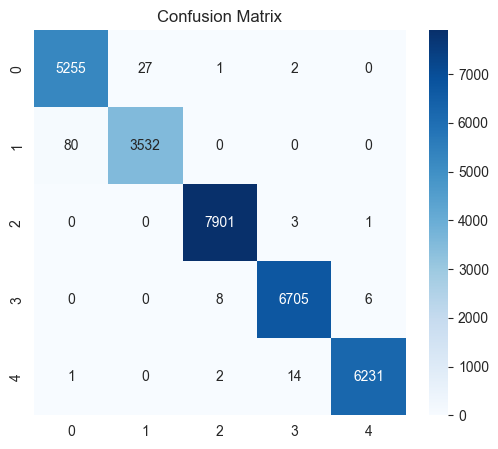

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

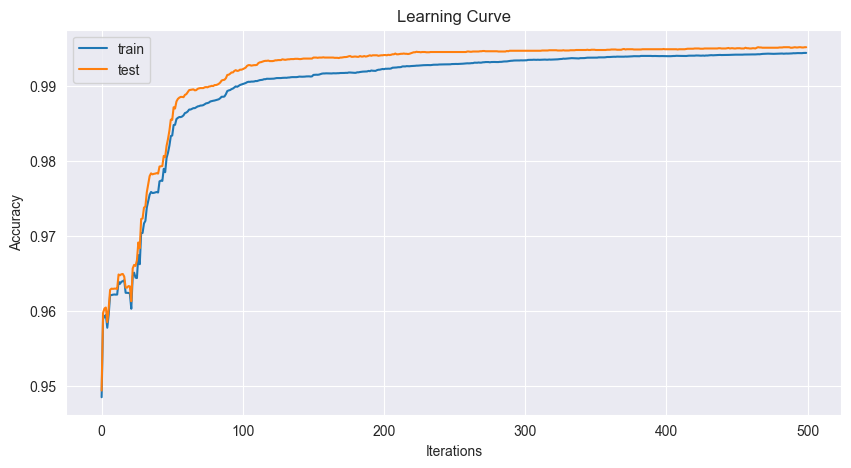

In [9]:
results = model.get_evals_result()

plt.figure(figsize=(10,5))
plt.plot(results['learn']['Accuracy'], label='train')
plt.plot(results['validation']['Accuracy'], label='test')
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.show()

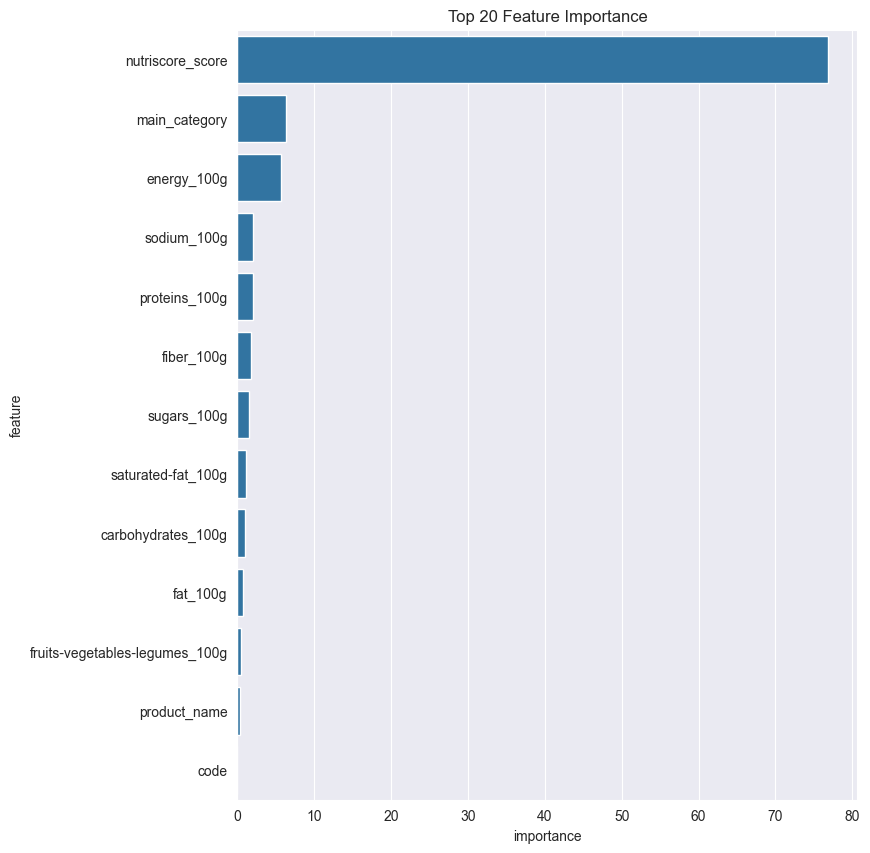

In [10]:
importances = model.get_feature_importance()

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(data=feat_imp.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importance")
plt.show()